In [3]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns


#In this project, I used exploratory data analysis to investigate potential leads for hypothesis testing, and pursued one I found interesting! 
#This is using NBA data! 

np.set_printoptions(suppress=True, precision = 2)

nba = pd.read_csv('./nba_games.csv')
# Lets explore the 1947 season and 2010 Season
nba_1947 = nba[nba.year_id == 1947]
nba_2010 = nba[nba.year_id == 2010]


The difference in means for 1947 is 5.010416666666664


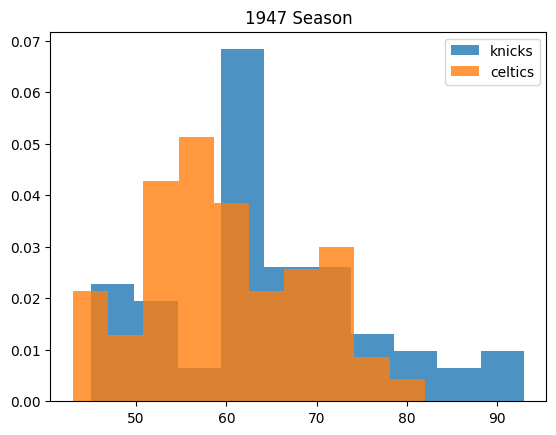

In [4]:
#lets look at the mean score of the Knicks and Celtics in 1947 

knicks_pts_1947 = nba_1947.pts[nba.fran_id=='Knicks']
knicks_mean = knicks_pts_1947.mean()

celtic_pts_1947 = nba_1947.pts[nba.fran_id=='Celtics']
celtic_mean = celtic_pts_1947.mean()

#Determine if there is a difference in the means between the Knicks and the Nets in 2010
diff_means_1947 = knicks_mean - celtic_mean

print("The difference in means for 1947 is " + str(diff_means_1947))

#There appears to be, so we compare the histograms representing the scores of each game in 1947 on the same chart, where we see minimal overlap! 
#This could be a lead for further hypothesis testing! 

plt.hist(knicks_pts_1947, alpha=0.8, density = True, label='knicks')
plt.hist(celtic_pts_1947, alpha=0.8, density = True, label='celtics')
plt.legend()
plt.title("1947 Season")
plt.show()



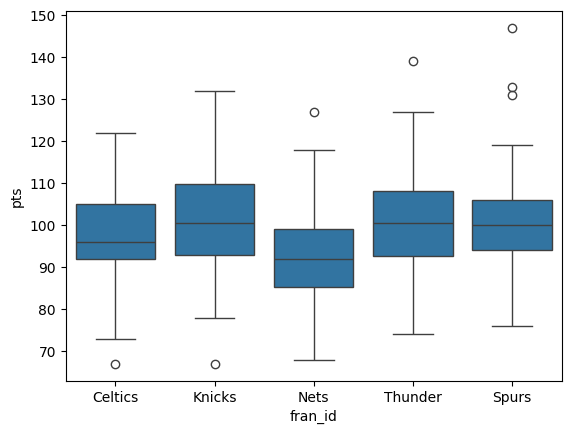

In [5]:
#lets see if there is any association between points per game and team in the 2010 season. A box plot will allow an easy comparison of this. 
#This appears to be another lead for hypothesis testing! 

plt.clf() #to clear the previous plot
sns.boxplot(data = nba_2010, x = nba_2010.fran_id, y = nba_2010.pts)
plt.show()

In [6]:
# I want to see if teams tend to win more at home or away. A contingency table for game_result and game_location will allow us to see an associaiton is
#plausible 

location_result_freq = pd.crosstab(nba_2010.game_result, nba_2010.game_location)
print(location_result_freq)
location_result_proportions = location_result_freq/len(nba_2010.game_location)

print(location_result_proportions)


game_location    A    H
game_result            
L              133  105
W               92  120
game_location         A         H
game_result                      
L              0.295556  0.233333
W              0.204444  0.266667


In [7]:
#There was a greater probability for a team to win at home versus away, which suggests there is an association. 
# Lets actually determine if this difference is statistically significant with a Chi Squared Test of Independence. 

chi2, pval, dof, expected = chi2_contingency(location_result_freq)

#Our expected contingency table is a lot different from our actual, and our chi squared test score is very high.  
#This suggests there is an association between location and winning! 

print(expected)
print(chi2)



[[119. 119.]
 [106. 106.]]
6.501704455367053


In [8]:

#538 has calculated the probability that each team will win the game. Using covariance, lets see if teams with a higher probability of winning, 
# win games by more points. 

#there appears to be a positive correlation when using covariance 
print(np.cov(nba_2010.forecast, nba_2010.point_diff))


#lets standardize our covariance to Pearsons R to interpret this more easily. We got a very sig P value!! which means there is a sig 
# positive correlation! 
point_diff_forecast_corr = pearsonr(nba_2010.forecast, nba_2010.point_diff)
print(point_diff_forecast_corr)



[[  0.05   1.37]
 [  1.37 186.56]]
PearsonRResult(statistic=np.float64(0.4402088708468082), pvalue=np.float64(9.410391573140234e-23))


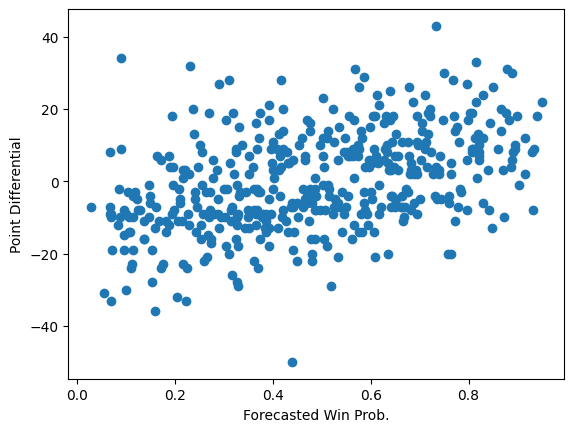

In [9]:
#We can confirm this conclusion makes sense, by looking for a visual trend on a scatter plot!

plt.clf() #to clear the previous plot
plt.scatter(nba_2010.forecast, nba_2010.point_diff)
plt.xlabel('Forecasted Win Prob.')
plt.ylabel('Point Differential')
plt.show()
